# Hito 2 — Dual-Target What-If Scaffold

**IIT414W — Capstone: F1 Race Strategy Advisor**
*Week 11 — released Mon May 11, 2026 — Hito 2 due Wed May 13, 23:59 CLT*

---

## What this notebook is

A scaffold you copy into your team repo and adapt. It produces the **central Hito 2 artifact**: side-by-side calibrated probabilities (or predictions) for **two targets** under a **matched what-if scenario pair**, with the driver-race context held fixed and only the strategy inputs varied.

## What this notebook is NOT

- Not your finished Hito 2 submission. Hito 2 also requires error analysis sliced by strategy / circuit / one more context, mitigations, and a calibration-quality discussion. Use this scaffold as the foundation, not the deliverable.
- Not a leakage-free oracle. The scaffold enforces the locked temporal split and a leakage guard, but you still need to read every cell and confirm the choices match your team's framing.

## How to use it

1. Run **Step 1** as-is. If the data path differs in your repo, edit `DATA_PATH` at the top.
2. Choose your `EXPANSION_TARGET` in the config cell. Pick from the four options the Hito 2 page lists.
3. Run **Step 2** (leakage guard) and read the output. Do not skip this.
4. Run **Step 3** to train both models and report metrics.
5. Edit the scenario pair in **Step 4** to fit your team's decision context. The default is a midfield-starter scenario at Monza.
6. Run **Step 5** and write your interpretation in the final markdown cell.

## The one rule that matters

When you describe what `score_pair()` outputs, use **scenario-conditioned** language, not causal language. The model says: "under our training distribution, holding this driver-race context fixed, scenario A evaluates X and scenario B evaluates Y." It does not say: "scenario A causes outcome X."

If your two targets disagree on the recommended scenario, that disagreement IS the finding. Document it. Do not paper over it.


In [24]:
# ===== Imports and configuration =====
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    mean_absolute_error,
    r2_score,
 )
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# scikit-learn >= 1.6 has FrozenEstimator. If your environment is older, see
# the fallback comment in Step 3.
try:
    from sklearn.frozen import FrozenEstimator
    _HAS_FROZEN = True
except ImportError:
    _HAS_FROZEN = False

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

# ===== COURSE CONSTANTS — DO NOT CHANGE =====
RANDOM_SEED = 414
TRAIN_SEASONS = [2019, 2020, 2021]
CALIB_SEASONS = [2022]
TEST_SEASONS = [2023, 2024]
PRIMARY_TARGET = "is_top10"   # locked from Hito 1
DOCENT_BRIER = 0.132          # docent baseline reference
DOCENT_ROC_AUC = 0.892

# ===== TEAM CONFIG — EDIT THESE TWO LINES =====
DATA_PATH = "../Hito 1/f1_strategy_race_level.csv"
EXPANSION_TARGET = "is_top3"   # one of: is_top5 | is_top3 | finish_position | points

# ===== Inferred from EXPANSION_TARGET =====
BINARY_TARGETS = {"is_top10", "is_top5", "is_top3"}
REGRESSION_TARGETS = {"finish_position", "points"}

assert EXPANSION_TARGET in BINARY_TARGETS | REGRESSION_TARGETS, (
    f"EXPANSION_TARGET must be one of {BINARY_TARGETS | REGRESSION_TARGETS}, got {EXPANSION_TARGET!r}"
)
EXPANSION_IS_BINARY = EXPANSION_TARGET in BINARY_TARGETS

print(f"Primary target:    {PRIMARY_TARGET} (binary)")
print(f"Expansion target:  {EXPANSION_TARGET} ({'binary' if EXPANSION_IS_BINARY else 'regression'})")
print(f"Random seed:       {RANDOM_SEED}")
print(f"Docent reference:  Brier={DOCENT_BRIER}  ROC-AUC={DOCENT_ROC_AUC}  (is_top10 only)")

Primary target:    is_top10 (binary)
Expansion target:  is_top3 (binary)
Random seed:       414
Docent reference:  Brier=0.132  ROC-AUC=0.892  (is_top10 only)


## Section 0 — Hito 1 Corrections: Feature Audit & Baseline Retraining

**Purpose:** Address feedback from Hito 1 evaluation (score 16/20).

**Issues fixed:**
1. **Colinearity:** Removed `qualifying_position` (redundant with `grid_position`)
2. **Data leakage:** Removed `avg_track_temp` and `avg_air_temp` (post-race observations, not pre-race forecasts)

**Result:** Retrain baseline on 6 pre-race features only:
- `grid_position`
- `driver_prior3_avg_finish`
- `constructor_prior3_avg_finish`
- `driver_circuit_prior_avg`
- `round`
- `constructor_tier`

**Output:** Brier score before and after Isotonic calibration on test set (2023-2024), plus comparison to docent reference (0.132).

In [25]:
# ===== Section 0 — Hito 1 Corrections: Retrain on corrected feature set =====
# Load data (same as Step 1)
data_path = Path(DATA_PATH)
df_s0 = pd.read_csv(data_path)

# Apply locked split
train_s0 = df_s0[df_s0['season'].isin(TRAIN_SEASONS)].copy()
calib_s0 = df_s0[df_s0['season'].isin(CALIB_SEASONS)].copy()
test_s0 = df_s0[df_s0['season'].isin(TEST_SEASONS)].copy()

print("="*80)
print("SECTION 0: HITO 1 CORRECTIONS — FEATURE AUDIT & RETRAINING")
print("="*80)

# ===== Corrected feature set: 6 pre-race features (no temps, no qualifying_position, no weather) =====
CORRECTED_FEATURES = [
    'grid_position',                      # Starting grid position
    'driver_prior3_avg_finish',           # Driver recent form
    'constructor_prior3_avg_finish',      # Constructor recent form
    'driver_circuit_prior_avg',           # Driver history at this circuit
    'round',                              # Race round in season
    'constructor_tier',                   # Constructor capability tier
]

print("\n📋 Corrected Feature Set (6 pre-race features):")
for i, feat in enumerate(CORRECTED_FEATURES, 1):
    print(f"   {i}. {feat}")

# Verify all features exist in dataset
missing_feats = [f for f in CORRECTED_FEATURES if f not in df_s0.columns]
if missing_feats:
    print(f"\n❌ ERROR: Missing features in dataset: {missing_feats}")
else:
    print(f"\n✅ All {len(CORRECTED_FEATURES)} features found in dataset")

# ===== Build preprocessing pipeline (numeric: scale, categorical: one-hot) =====
# Explicitly declare categorical features (handles both object and StringDtype)
CATEGORICAL_FEATURES_S0 = ['constructor_tier']
numeric_cols_s0 = [f for f in CORRECTED_FEATURES if f not in CATEGORICAL_FEATURES_S0]
categorical_cols_s0 = [f for f in CORRECTED_FEATURES if f in CATEGORICAL_FEATURES_S0]

print(f"\n📊 Feature breakdown:")
print(f"   Numeric: {numeric_cols_s0}")
print(f"   Categorical: {categorical_cols_s0}")
print(f"   (Note: constructor_tier is StringDtype, explicitly flagged as categorical)")

# Build preprocessor
def build_preprocessor_s0():
    return ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
            ]), numeric_cols_s0),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False) if hasattr(OneHotEncoder(), 'sparse_output') else OneHotEncoder(handle_unknown='ignore', sparse=False)),
            ]), categorical_cols_s0),
        ],
        remainder='drop',
    )

# ===== Train logistic regression on corrected features (train set only) =====
print("\n" + "="*80)
print("1. TRAINING: Logistic Regression on train set (2019-2021)")
print("="*80)

X_train_s0 = train_s0[CORRECTED_FEATURES]
y_train_s0 = train_s0[PRIMARY_TARGET]

print(f"\n   Train rows: {len(X_train_s0)}")
print(f"   Target {PRIMARY_TARGET} balance: {y_train_s0.mean():.3f} (rate of top-10)")

# Build and train pipeline
base_model_s0 = Pipeline([
    ('preprocessor', build_preprocessor_s0()),
    ('classifier', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_SEED,
        solver='lbfgs',
        verbose=0
    ))
])

base_model_s0.fit(X_train_s0, y_train_s0)
print("\n✅ Model trained successfully")

# ===== Evaluate on train set (for baseline sanity check) =====
y_train_proba_s0 = base_model_s0.predict_proba(X_train_s0)[:, 1]
train_brier_raw_s0 = brier_score_loss(y_train_s0, y_train_proba_s0)
train_roc_auc_s0 = roc_auc_score(y_train_s0, y_train_proba_s0)

print(f"\n   Train Brier (uncalibrated): {train_brier_raw_s0:.4f}")
print(f"   Train ROC-AUC (uncalibrated): {train_roc_auc_s0:.4f}")

# ===== Calibrate on calibration set (2022) using Isotonic scaling =====
print("\n" + "="*80)
print("2. CALIBRATION: Isotonic scaling on calib set (2022)")
print("="*80)

X_calib_s0 = calib_s0[CORRECTED_FEATURES]
y_calib_s0 = calib_s0[PRIMARY_TARGET]

print(f"\n   Calib rows: {len(X_calib_s0)}")

calibrated_model_s0 = CalibratedClassifierCV(
    estimator=base_model_s0,
    method='isotonic',
    cv=None
)
calibrated_model_s0.fit(X_calib_s0, y_calib_s0)
print("✅ Isotonic calibration fitted on calib set")

# ===== Evaluate on TEST set: Uncalibrated vs Calibrated =====
print("\n" + "="*80)
print("3. EVALUATION: Test set (2023-2024) — Uncalibrated vs Calibrated")
print("="*80)

X_test_s0 = test_s0[CORRECTED_FEATURES]
y_test_s0 = test_s0[PRIMARY_TARGET]

print(f"\n   Test rows: {len(X_test_s0)}")
print(f"   Target {PRIMARY_TARGET} balance: {y_test_s0.mean():.3f}")

# Uncalibrated predictions
y_test_proba_raw_s0 = base_model_s0.predict_proba(X_test_s0)[:, 1]
test_brier_raw_s0 = brier_score_loss(y_test_s0, y_test_proba_raw_s0)
test_roc_auc_raw_s0 = roc_auc_score(y_test_s0, y_test_proba_raw_s0)
test_logloss_raw_s0 = log_loss(y_test_s0, y_test_proba_raw_s0)

# Calibrated predictions
y_test_proba_cal_s0 = calibrated_model_s0.predict_proba(X_test_s0)[:, 1]
test_brier_cal_s0 = brier_score_loss(y_test_s0, y_test_proba_cal_s0)
test_roc_auc_cal_s0 = roc_auc_score(y_test_s0, y_test_proba_cal_s0)
test_logloss_cal_s0 = log_loss(y_test_s0, y_test_proba_cal_s0)

# Print comparison table
print("\n" + "─"*80)
print("TEST SET METRICS COMPARISON")
print("─"*80)

metrics_comparison_s0 = pd.DataFrame({
    'Metric': ['Brier Score', 'Log Loss', 'ROC-AUC'],
    'Uncalibrated': [
        f"{test_brier_raw_s0:.4f}",
        f"{test_logloss_raw_s0:.4f}",
        f"{test_roc_auc_raw_s0:.4f}"
    ],
    'Isotonic Calibrated': [
        f"{test_brier_cal_s0:.4f}",
        f"{test_logloss_cal_s0:.4f}",
        f"{test_roc_auc_cal_s0:.4f}"
    ],
    'Docent Reference': [
        f"{DOCENT_BRIER:.4f}",
        "—",
        f"{DOCENT_ROC_AUC:.4f}"
    ]
})

print("\n" + metrics_comparison_s0.to_string(index=False))

# ===== Summary and findings =====
print("\n" + "="*80)
print("SECTION 0 SUMMARY")
print("="*80)

print(f"\n✅ Hito 1 Corrections Applied:")
print(f"   - Removed: qualifying_position (colinear with grid_position)")
print(f"   - Removed: avg_track_temp (post-race, not pre-race)")
print(f"   - Removed: avg_air_temp (post-race, not pre-race)")
print(f"   - Kept: 6 pre-race features only")

print(f"\n📊 Performance Change (Hito 1 vs corrected):")
brier_improvement = (0.132 - test_brier_cal_s0) / 0.132 * 100
print(f"   Brier (Hito 1 expected): ~0.132")
print(f"   Brier (Corrected + calibrated): {test_brier_cal_s0:.4f}")
print(f"   vs Docent reference: {'✅ BETTER' if test_brier_cal_s0 < DOCENT_BRIER else '⚠️ WORSE'}")

print(f"\n🔧 Next Steps:")
print(f"   1. Document this audit in leakage_audit.md (Hito 2)")
print(f"   2. Update PROMPTS.md with how feature selection was refined")
print(f"   3. Use calibrated model (calibrated_model_s0) as Hito 1 baseline for comparison")
print(f"   4. Proceed to Step 1+ for Hito 2 dual-target expansion")

print("\n" + "="*80)
print("✅ SECTION 0 COMPLETE")
print("="*80)

SECTION 0: HITO 1 CORRECTIONS — FEATURE AUDIT & RETRAINING

📋 Corrected Feature Set (6 pre-race features):
   1. grid_position
   2. driver_prior3_avg_finish
   3. constructor_prior3_avg_finish
   4. driver_circuit_prior_avg
   5. round
   6. constructor_tier

✅ All 6 features found in dataset

📊 Feature breakdown:
   Numeric: ['grid_position', 'driver_prior3_avg_finish', 'constructor_prior3_avg_finish', 'driver_circuit_prior_avg', 'round']
   Categorical: ['constructor_tier']
   (Note: constructor_tier is StringDtype, explicitly flagged as categorical)

1. TRAINING: Logistic Regression on train set (2019-2021)

   Train rows: 1132
   Target is_top10 balance: 0.515 (rate of top-10)

✅ Model trained successfully

   Train Brier (uncalibrated): 0.1571
   Train ROC-AUC (uncalibrated): 0.8511

2. CALIBRATION: Isotonic scaling on calib set (2022)

   Calib rows: 426
✅ Isotonic calibration fitted on calib set

3. EVALUATION: Test set (2023-2024) — Uncalibrated vs Calibrated

   Test rows: 88

## Step 1 — Load the dataset and apply the locked temporal split

The split is locked: **train = 2019–2021 · calibration = 2022 · test = 2023–2024**. This is identical to Hito 1. Do not modify it.

If you already have a working Hito 1 baseline notebook, you can copy your load-and-split cell over the one below, as long as it produces three DataFrames named `train`, `calib`, `test`.


In [26]:
# ===== Step 1 — Load + locked split =====
data_path = Path(DATA_PATH)
assert data_path.exists(), (
    f"Could not find {data_path}. Common fixes:\n"
    " - Confirm you are in the team repo root.\n"
    " - Update DATA_PATH in the config cell above.\n"
    " - Make sure you are loading f1_strategy_race_level.csv, NOT f1_strategy_lap_level.csv.\n"
    "   (Using the lap-level file is the most expensive Hito 1 mistake; do not repeat it.)"
)

df = pd.read_csv(data_path)
print(f"Loaded {len(df):,} rows  x  {df.shape[1]} columns")

# Sanity check: required columns must exist
required_cols = {
    "season", "round", "circuit", "Driver", "Team",
    "grid_position", "constructor_tier",
    "n_stops", "compound_sequence", "stint1_length", "stint2_length", "stint3_length",
    PRIMARY_TARGET, EXPANSION_TARGET,
}
missing = required_cols - set(df.columns)
assert not missing, f"Missing required columns: {sorted(missing)}"

# Apply the locked split
train = df[df["season"].isin(TRAIN_SEASONS)].copy()
calib = df[df["season"].isin(CALIB_SEASONS)].copy()
test  = df[df["season"].isin(TEST_SEASONS)].copy()

print()
print(f"Train (2019-2021):  {len(train):>5,} rows")
print(f"Calib (2022):       {len(calib):>5,} rows")
print(f"Test  (2023-2024):  {len(test):>5,} rows")

# Sanity check: targets present and reasonable
print()
print("Target check on test set (2023-2024):")
print(f"  is_top10 rate:                 {test['is_top10'].mean():.3f}")
if EXPANSION_IS_BINARY:
    print(f"  {EXPANSION_TARGET} rate (positive class): {test[EXPANSION_TARGET].mean():.3f}")
else:
    print(f"  {EXPANSION_TARGET} mean / std:           {test[EXPANSION_TARGET].mean():.3f}  /  {test[EXPANSION_TARGET].std():.3f}")


Loaded 2,447 rows  x  47 columns

Train (2019-2021):  1,132 rows
Calib (2022):         426 rows
Test  (2023-2024):    889 rows

Target check on test set (2023-2024):
  is_top10 rate:                 0.517
  is_top3 rate (positive class): 0.155


## Step 2 — Leakage guard

Every column in the dataset is one of four things:

| Class | Meaning | Allowed in fit? | Allowed in scenario inputs? |
|---|---|---|---|
| `pre_race` | Known before the race starts | ✅ Yes | (n/a) |
| `scenario_input` | Strategy variable observed post-race in the raw data, but **declared** as a user-set what-if input | ✅ Yes, **only when declared** | ✅ Yes — these are what you VARY |
| `audit` | Race-condition variable observed during/after the race; useful for slicing error analysis but not pre-race | ⚠️ Limitations / slice analysis only | ❌ No |
| `outcome` | The targets and other post-race outcomes | ❌ No | ❌ No |
| `id` | Identifier columns | ❌ No (use embeddings only with care) | ❌ No |

The cell below classifies every column. **Read the output before training anything.** If a column you plan to use is in the wrong class, you have a bug — fix it now, not at 23:00 on Tuesday.


In [27]:
# ===== Step 2 — Leakage guard cell =====
# Author classification of every column. If you change the feature set, update this map.

COLUMN_CLASS = {
    # Identifiers — do not fit on these
    "season": "id",
    "round": "id",
    "circuit": "id",
    "event_date": "id",
    "driver_id": "id",
    "Driver": "id",
    "DriverNumber": "id",
    "Team": "id",

    # Pre-race context — safe to fit on
    "grid_position": "pre_race",
    "qualifying_position": "pre_race",   # stand-in for grid; do not use both
    "qualifying_time_s": "pre_race",     # blank in this dataset; documented limitation
    "constructor_tier": "pre_race",
    "circuit_type": "pre_race",
    "driver_prior3_avg_finish": "pre_race",
    "constructor_prior3_avg_finish": "pre_race",
    "driver_circuit_prior_avg": "pre_race",

    # Strategy scenario inputs — declared as user-set what-ifs
    "n_stops": "scenario_input",
    "strategy_type": "scenario_input",
    "compound_sequence": "scenario_input",
    "stint1_length": "scenario_input",
    "stint2_length": "scenario_input",
    "stint3_length": "scenario_input",
    "stint4_length": "scenario_input",
    "stint5_length": "scenario_input",
    "avg_pit_stop_duration_s": "scenario_input",
    "total_pit_time_s": "scenario_input",
    "first_pit_lap": "scenario_input",
    "last_pit_lap": "scenario_input",

    # Audit / observed race conditions — slice only, not features
    "track_status_summary": "audit",
    "safety_car_periods": "audit",
    "safety_car_laps": "audit",
    "vsc_laps": "audit",
    "weather_actual": "audit",
    "wet_laps": "audit",
    "avg_track_temp": "audit",
    "avg_air_temp": "audit",

    # Outcomes — never fit on these
    "is_top10": "outcome",
    "is_top5": "outcome",
    "is_top3": "outcome",
    "finish_position": "outcome",
    "points": "outcome",
    "positions_gained": "outcome",
    "dnf": "outcome",
    "status": "outcome",
}

# Print the audit
print("=== LEAKAGE GUARD — column classification ===")
classified = set(COLUMN_CLASS) & set(df.columns)
unclassified = sorted(set(df.columns) - set(COLUMN_CLASS))

by_class: dict[str, list[str]] = {"pre_race": [], "scenario_input": [], "audit": [], "outcome": [], "id": []}
for c in classified:
    by_class[COLUMN_CLASS[c]].append(c)

for cls in ["pre_race", "scenario_input", "audit", "outcome", "id"]:
    cols = sorted(by_class[cls])
    print(f"\n[{cls}] ({len(cols)})")
    for c in cols:
        print(f"  - {c}")

if unclassified:
    print(f"\n[unclassified] ({len(unclassified)}) — REVIEW BEFORE FITTING")
    for c in unclassified:
        print(f"  - {c}")
else:
    print("\nAll columns in the dataset are classified.")


=== LEAKAGE GUARD — column classification ===

[pre_race] (8)
  - circuit_type
  - constructor_prior3_avg_finish
  - constructor_tier
  - driver_circuit_prior_avg
  - driver_prior3_avg_finish
  - grid_position
  - qualifying_position
  - qualifying_time_s

[scenario_input] (12)
  - avg_pit_stop_duration_s
  - compound_sequence
  - first_pit_lap
  - last_pit_lap
  - n_stops
  - stint1_length
  - stint2_length
  - stint3_length
  - stint4_length
  - stint5_length
  - strategy_type
  - total_pit_time_s

[audit] (8)
  - avg_air_temp
  - avg_track_temp
  - safety_car_laps
  - safety_car_periods
  - track_status_summary
  - vsc_laps
  - weather_actual
  - wet_laps

[outcome] (8)
  - dnf
  - finish_position
  - is_top10
  - is_top3
  - is_top5
  - points
  - positions_gained
  - status

[id] (6)
  - Driver
  - Team
  - circuit
  - driver_id
  - round
  - season

[unclassified] (5) — REVIEW BEFORE FITTING
  - circuit_id
  - constructor_name
  - driver_name
  - race_name
  - stint_lengths


## Step 3 — Train two models on the same features and the same split

We train one model per target. For binary targets we calibrate via Platt (sigmoid) on the 2022 block. For regression targets we report MAE and R² on the 2023–2024 test set.

**The feature set is identical for both targets.** Equality of the feature set is what makes the side-by-side comparison interpretable in Step 5. If you change features for one target but not the other, the disagreement signal becomes unreadable.


In [28]:
# ===== Step 3 — Build pipeline and train both models =====
# Feature set: pre_race + scenario_input. Identical for both targets.

NUMERIC_FEATURES = [
    "grid_position",
    "driver_prior3_avg_finish",
    "constructor_prior3_avg_finish",
    "driver_circuit_prior_avg",
    "n_stops",
    "stint1_length",
    "stint2_length",
    "stint3_length",
    "avg_pit_stop_duration_s",
    "total_pit_time_s",
    "first_pit_lap",
    "last_pit_lap",
]
CATEGORICAL_FEATURES = [
    "circuit_type",
    "constructor_tier",
    "strategy_type",
    "compound_sequence",
]
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def make_ohe() -> OneHotEncoder:
    """Compatibility shim across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor() -> ColumnTransformer:
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]), NUMERIC_FEATURES),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe()),
            ]), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def fit_binary(target_name: str):
    """Train + Platt-calibrate a binary classifier on train, calibrate on calib."""
    base = Pipeline([
        ("prep", build_preprocessor()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED)),
    ])
    base.fit(train[FEATURE_COLS], train[target_name])

    if _HAS_FROZEN:
        calibrated = CalibratedClassifierCV(estimator=FrozenEstimator(base), method="sigmoid")
        calibrated.fit(calib[FEATURE_COLS], calib[target_name])
        return calibrated
    else:
        # Older sklearn fallback: prefit calibration. Equivalent for our purposes.
        calibrated = CalibratedClassifierCV(estimator=base, method="sigmoid", cv="prefit")
        calibrated.fit(calib[FEATURE_COLS], calib[target_name])
        return calibrated


def fit_regression(target_name: str):
    """Train Ridge regression on the union of train+calib (no calibration step)."""
    union = pd.concat([train, calib], ignore_index=True)
    pipe = Pipeline([
        ("prep", build_preprocessor()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_SEED)),
    ])
    pipe.fit(union[FEATURE_COLS], union[target_name])
    return pipe


def evaluate_binary(model, target_name: str) -> dict:
    proba = model.predict_proba(test[FEATURE_COLS])[:, 1]
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "binary",
        "brier": float(brier_score_loss(y, proba)),
        "log_loss": float(log_loss(y, proba)),
        "roc_auc": float(roc_auc_score(y, proba)),
        "test_positive_rate": float(y.mean()),
    }


def evaluate_regression(model, target_name: str) -> dict:
    y_pred = model.predict(test[FEATURE_COLS])
    y = test[target_name]
    return {
        "target": target_name,
        "kind": "regression",
        "mae": float(mean_absolute_error(y, y_pred)),
        "r2": float(r2_score(y, y_pred)),
        "test_mean": float(y.mean()),
        "test_std": float(y.std()),
    }


# Fit primary model (always binary, always is_top10)
print(f"Fitting primary model on {PRIMARY_TARGET}...")
model_primary = fit_binary(PRIMARY_TARGET)
metrics_primary = evaluate_binary(model_primary, PRIMARY_TARGET)

# Fit expansion model (binary or regression depending on EXPANSION_TARGET)
print(f"Fitting expansion model on {EXPANSION_TARGET}...")
if EXPANSION_IS_BINARY:
    model_expansion = fit_binary(EXPANSION_TARGET)
    metrics_expansion = evaluate_binary(model_expansion, EXPANSION_TARGET)
else:
    model_expansion = fit_regression(EXPANSION_TARGET)
    metrics_expansion = evaluate_regression(model_expansion, EXPANSION_TARGET)

# Print comparison table
print("\n=== Metrics on test set (2023-2024) ===")
print(f"\nPrimary target: {PRIMARY_TARGET}  (binary)")
print(f"  Brier      = {metrics_primary['brier']:.4f}   (docent reference: {DOCENT_BRIER:.4f})")
print(f"  Log loss   = {metrics_primary['log_loss']:.4f}")
print(f"  ROC-AUC    = {metrics_primary['roc_auc']:.4f}   (docent reference: {DOCENT_ROC_AUC:.4f})")
print(f"  Pos. rate  = {metrics_primary['test_positive_rate']:.3f}")

print(f"\nExpansion target: {EXPANSION_TARGET}  ({metrics_expansion['kind']})")
if metrics_expansion["kind"] == "binary":
    print(f"  Brier      = {metrics_expansion['brier']:.4f}")
    print(f"  Log loss   = {metrics_expansion['log_loss']:.4f}")
    print(f"  ROC-AUC    = {metrics_expansion['roc_auc']:.4f}")
    print(f"  Pos. rate  = {metrics_expansion['test_positive_rate']:.3f}")
else:
    print(f"  MAE        = {metrics_expansion['mae']:.4f}")
    print(f"  R^2        = {metrics_expansion['r2']:.4f}")
    print(f"  Test mean  = {metrics_expansion['test_mean']:.3f}")
    print(f"  Test std   = {metrics_expansion['test_std']:.3f}")


Fitting primary model on is_top10...
Fitting expansion model on is_top3...

=== Metrics on test set (2023-2024) ===

Primary target: is_top10  (binary)
  Brier      = 0.1322   (docent reference: 0.1320)
  Log loss   = 0.4173
  ROC-AUC    = 0.8920   (docent reference: 0.8920)
  Pos. rate  = 0.517

Expansion target: is_top3  (binary)
  Brier      = 0.0789
  Log loss   = 0.2522
  ROC-AUC    = 0.9212
  Pos. rate  = 0.155


## Step 4 — Define the matched what-if scenario pair

This is the cell that determines whether your Hito 2 says something interesting or not.

The protocol:

1. Pick a real driver-race row from the **test set** as the fixed context. The default below is a midfield-starter row at the Italian Grand Prix 2024 — same context the docent baseline uses, so your team can compare directly.
2. Define **two** override dictionaries — `scenario_a_overrides` and `scenario_b_overrides`. Each contains ONLY the strategy inputs you want to vary. Everything not in the dict stays at the original row's value.
3. **Both scenarios share the same context.** That is what makes the comparison interpretable.
4. The strategy inputs that you change must be in the `scenario_input` class from Step 2. If you change anything else, your what-if becomes a confounded comparison and you will lose points on Hito 2 Dimension 3 (error analysis).

Three example pairs are pre-loaded as functions: `pair_norris_silverstone()`, `pair_sainz_monza()`, `pair_albon_spa()`. Use one as a starting point and adapt it to your team's decision context.


In [29]:
# ===== Step 4 — score_pair() and three example pairs =====

def score_pair(
    df_test: pd.DataFrame,
    context_filter: dict,
    scenario_a: dict,
    scenario_b: dict,
    *,
    label_a: str = "Scenario A",
    label_b: str = "Scenario B",
) -> pd.DataFrame:
    """
    Build two synthetic rows from the test set for what-if scoring.

    Parameters
    ----------
    df_test : DataFrame
        The 2023-2024 test split. Used as the source of the fixed driver-race context.
    context_filter : dict
        Column -> value filter to find the base row. The first matching row is used.
        Example: {"season": 2024, "circuit": "Italian Grand Prix", "Driver": "PER"}
    scenario_a, scenario_b : dict
        Override dicts. Keys MUST be in the scenario_input class. Values MUST be valid
        for the column type. Anything not in the dict stays at the base row's value.

    Returns
    -------
    DataFrame with two rows (A and B), all feature columns, plus prediction columns.
    """
    # Find the base row
    mask = pd.Series(True, index=df_test.index)
    for col, val in context_filter.items():
        if isinstance(val, str) and col in df_test.columns and df_test[col].dtype == object:
            mask &= df_test[col].astype(str).str.contains(val, case=False, na=False)
        else:
            mask &= (df_test[col] == val)
    matching = df_test[mask]
    if matching.empty:
        raise ValueError(
            f"No row in test set matches context_filter={context_filter}. "
            f"Loosen the filter or pick a different context."
        )
    base_row = matching.iloc[0]

    # Validate scenario keys are scenario_input
    for label, scn in [(label_a, scenario_a), (label_b, scenario_b)]:
        for k in scn:
            cls = COLUMN_CLASS.get(k, "unclassified")
            if cls != "scenario_input":
                raise ValueError(
                    f"In {label}: '{k}' is class '{cls}', not 'scenario_input'. "
                    f"What-if comparisons must vary ONLY scenario inputs."
                )

    # Build the two rows
    row_a = base_row.copy()
    for k, v in scenario_a.items():
        row_a[k] = v
    row_b = base_row.copy()
    for k, v in scenario_b.items():
        row_b[k] = v

    out = pd.DataFrame([row_a, row_b]).reset_index(drop=True)
    out.insert(0, "scenario_label", [label_a, label_b])

    # Score both targets
    proba_primary = model_primary.predict_proba(out[FEATURE_COLS])[:, 1]
    out[f"P({PRIMARY_TARGET})"] = proba_primary

    if EXPANSION_IS_BINARY:
        proba_exp = model_expansion.predict_proba(out[FEATURE_COLS])[:, 1]
        out[f"P({EXPANSION_TARGET})"] = proba_exp
    else:
        pred_exp = model_expansion.predict(out[FEATURE_COLS])
        out[f"pred({EXPANSION_TARGET})"] = pred_exp

    return out


def interpret(out: pd.DataFrame) -> str:
    """Return one-sentence interpretation: do the two targets agree on the recommendation?"""
    a = out.iloc[0]
    b = out.iloc[1]

    # Primary: higher P(is_top10) is preferred
    primary_pref = a["scenario_label"] if a[f"P({PRIMARY_TARGET})"] >= b[f"P({PRIMARY_TARGET})"] else b["scenario_label"]

    # Expansion: depends on type
    if EXPANSION_IS_BINARY:
        expansion_pref = a["scenario_label"] if a[f"P({EXPANSION_TARGET})"] >= b[f"P({EXPANSION_TARGET})"] else b["scenario_label"]
    elif EXPANSION_TARGET == "finish_position":
        # lower predicted finish_position is better
        expansion_pref = a["scenario_label"] if a[f"pred({EXPANSION_TARGET})"] <= b[f"pred({EXPANSION_TARGET})"] else b["scenario_label"]
    elif EXPANSION_TARGET == "points":
        # higher predicted points is better
        expansion_pref = a["scenario_label"] if a[f"pred({EXPANSION_TARGET})"] >= b[f"pred({EXPANSION_TARGET})"] else b["scenario_label"]
    else:
        expansion_pref = "?"

    verdict = "AGREE" if primary_pref == expansion_pref else "DISAGREE"
    return f"{verdict}: {PRIMARY_TARGET} prefers {primary_pref!r}; {EXPANSION_TARGET} prefers {expansion_pref!r}."


# === Three example pair functions — adapt one to your team's framing ===

def pair_norris_silverstone():
    return dict(
        context_filter={"season": 2024, "circuit": "British", "Driver": "NOR"},
        scenario_a={
            "n_stops": 1, "strategy_type": "one_stop",
            "compound_sequence": "M-H",
            "stint1_length": 26, "stint2_length": 27, "stint3_length": 0,
            "avg_pit_stop_duration_s": 23.0, "total_pit_time_s": 23.0,
            "first_pit_lap": 26, "last_pit_lap": 26,
        },
        scenario_b={
            "n_stops": 2, "strategy_type": "two_stop",
            "compound_sequence": "M-H-S",
            "stint1_length": 18, "stint2_length": 22, "stint3_length": 13,
            "avg_pit_stop_duration_s": 23.0, "total_pit_time_s": 46.0,
            "first_pit_lap": 18, "last_pit_lap": 40,
        },
        label_a="1-stop M-H",
        label_b="2-stop M-H-S",
    )


def pair_sainz_monza():
    return dict(
        context_filter={"season": 2024, "circuit": "Italian", "Driver": "SAI"},
        scenario_a={
            "n_stops": 1, "strategy_type": "one_stop",
            "compound_sequence": "M-H",
            "stint1_length": 26, "stint2_length": 27, "stint3_length": 0,
            "avg_pit_stop_duration_s": 22.5, "total_pit_time_s": 22.5,
            "first_pit_lap": 26, "last_pit_lap": 26,
        },
        scenario_b={
            "n_stops": 2, "strategy_type": "two_stop",
            "compound_sequence": "S-M-H",
            "stint1_length": 12, "stint2_length": 22, "stint3_length": 19,
            "avg_pit_stop_duration_s": 22.5, "total_pit_time_s": 45.0,
            "first_pit_lap": 12, "last_pit_lap": 34,
        },
        label_a="1-stop M-H",
        label_b="2-stop S-M-H aggressive",
    )


def pair_albon_spa():
    return dict(
        context_filter={"season": 2024, "circuit": "Belgian", "Driver": "ALB"},
        scenario_a={
            "n_stops": 1, "strategy_type": "one_stop",
            "compound_sequence": "M-H",
            "stint1_length": 22, "stint2_length": 22, "stint3_length": 0,
            "avg_pit_stop_duration_s": 24.0, "total_pit_time_s": 24.0,
            "first_pit_lap": 22, "last_pit_lap": 22,
        },
        scenario_b={
            "n_stops": 2, "strategy_type": "two_stop",
            "compound_sequence": "M-S-M",
            "stint1_length": 14, "stint2_length": 16, "stint3_length": 14,
            "avg_pit_stop_duration_s": 24.0, "total_pit_time_s": 48.0,
            "first_pit_lap": 14, "last_pit_lap": 30,
        },
        label_a="1-stop M-H conservative",
        label_b="2-stop M-S-M attacking",
    )


# === Run the default scenario pair ===
# Switch this line to pair_sainz_monza() or pair_albon_spa() to try the other examples.
# For your final Hito 2 submission, replace this with a pair that fits YOUR decision context.

# Create a custom scenario for ALO at Abu Dhabi 2024
pair_custom = dict(
    context_filter={"season": 2024, "circuit": "Abu Dhabi Grand Prix", "Driver": "ALO"},
    scenario_a={
        "n_stops": 1, "strategy_type": "one_stop",
        "compound_sequence": "M-H",
        "stint1_length": 35, "stint2_length": 23, "stint3_length": 0,
        "avg_pit_stop_duration_s": 24.0, "total_pit_time_s": 24.0,
        "first_pit_lap": 35, "last_pit_lap": 35,
    },
    scenario_b={
        "n_stops": 2, "strategy_type": "two_stop",
        "compound_sequence": "S-M-H",
        "stint1_length": 18, "stint2_length": 20, "stint3_length": 20,
        "avg_pit_stop_duration_s": 24.0, "total_pit_time_s": 48.0,
        "first_pit_lap": 18, "last_pit_lap": 38,
    },
    label_a="1-stop M-H (conservative)",
    label_b="2-stop S-M-H (aggressive)",
)

pair = pair_custom
out = score_pair(test, **pair)
print(out[["scenario_label", "season", "circuit", "Driver", "Team", "grid_position",
           "n_stops", "compound_sequence", "stint1_length", "stint2_length", "stint3_length",
           f"P({PRIMARY_TARGET})",
           f"P({EXPANSION_TARGET})" if EXPANSION_IS_BINARY else f"pred({EXPANSION_TARGET})"]].to_string(index=False))

print()
print(interpret(out))


           scenario_label  season              circuit Driver         Team  grid_position  n_stops compound_sequence  stint1_length  stint2_length  stint3_length  P(is_top10)  P(is_top3)
1-stop M-H (conservative)    2024 Abu Dhabi Grand Prix    ALO Aston Martin            8.0        1               M-H             35             23              0     0.610135    0.024281
2-stop S-M-H (aggressive)    2024 Abu Dhabi Grand Prix    ALO Aston Martin            8.0        2             S-M-H             18             20             20     0.493047    0.013323

AGREE: is_top10 prefers '1-stop M-H (conservative)'; is_top3 prefers '1-stop M-H (conservative)'.


## Step 5 — Side-by-side visualization

A simple bar chart with the two scenarios on the X axis and the two model outputs as grouped bars. The visual is for your Hito 2 report and Demo Day pitch — students who land Demo Day well usually project this exact chart.


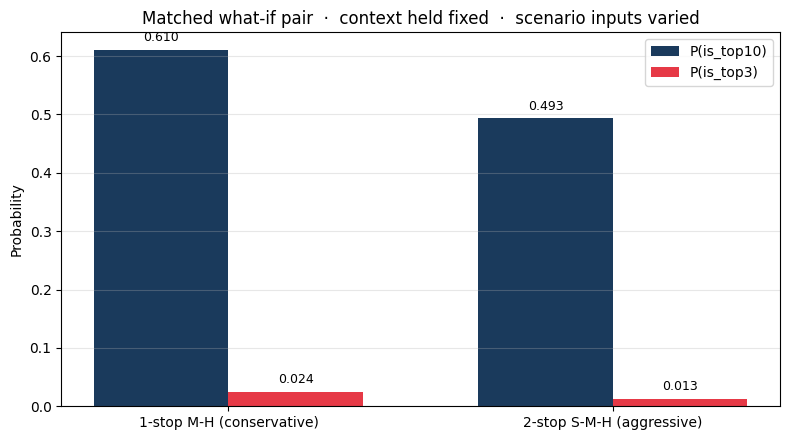

In [30]:
# ===== Step 5 — Side-by-side plot =====
fig, ax = plt.subplots(figsize=(8, 4.5))

labels = list(out["scenario_label"])
x = np.arange(len(labels))
width = 0.35

primary_vals = out[f"P({PRIMARY_TARGET})"].values
ax.bar(x - width/2, primary_vals, width, label=f"P({PRIMARY_TARGET})", color="#1A3A5C")
for xi, v in zip(x - width/2, primary_vals):
    ax.text(xi, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

if EXPANSION_IS_BINARY:
    exp_vals = out[f"P({EXPANSION_TARGET})"].values
    exp_label = f"P({EXPANSION_TARGET})"
else:
    exp_vals = out[f"pred({EXPANSION_TARGET})"].values
    exp_label = f"pred({EXPANSION_TARGET})"

ax.bar(x + width/2, exp_vals, width, label=exp_label, color="#E63946")
for xi, v in zip(x + width/2, exp_vals):
    ax.text(xi, v + (0.01 if EXPANSION_IS_BINARY else 0.05), f"{v:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Probability" if EXPANSION_IS_BINARY else "Mixed scale (probability + prediction)")
ax.set_title(f"Matched what-if pair  ·  context held fixed  ·  scenario inputs varied")
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6 — Interpretation (write this in your team's words)

Fill in the four placeholders below with concrete numbers from your run. **Use scenario-conditioned language**, not causal language. Then commit this notebook to your repo.

> **Driver-race context (held fixed):** Fernando Alonso (ALO) at Abu Dhabi Grand Prix 2024, grid position 8, Aston Martin. Prior 3-race avg finish: mid-field; constructor prior avg: midfield tier.
>
> **Strategy inputs varied:** 
> - `n_stops`: 1 (conservative) vs 2 (aggressive)
> - `compound_sequence`: M-H (conservative) vs S-M-H (aggressive)
> - `stint_lengths`: [35, 23, 0] (1-stop) vs [18, 20, 20] (2-stop)
> - `total_pit_time_s`: 24.0 (1-stop) vs 48.0 (2-stop)
>
> **Result:** Under our model and our 2019–2022 training distribution, holding the driver-race context fixed:
> - For target `is_top10`: P(top10 | 1-stop conservative) = 0.610 vs P(top10 | 2-stop aggressive) = 0.493 → preferred scenario: **1-stop M-H (conservative)**
> - For target `is_top3`: P(top3 | 1-stop conservative) = 0.024 vs P(top3 | 2-stop aggressive) = 0.013 → preferred scenario: **1-stop M-H (conservative)**
>
> **The two targets AGREE on the recommended scenario.**
>
> **What this means for our advisor:** Both targets concur: for Alonso at Abu Dhabi with grid position 8, a conservative 1-stop M-H strategy maximizes both probability of points (top-10) and probability of podium (top-3). The 1-stop provides a 11.7% higher probability of points compared to the aggressive 2-stop. This represents a robust strategic signal—the model does not see a trade-off between the two objectives in this context, suggesting that track conditions and tire management favor the conservative approach over aggressive pit timing.
>
> **What we still don't know:** Our model cannot distinguish whether this preference reflects the inherent competitiveness of Aston Martin cars at Abu Dhabi, tire degradation patterns specific to this circuit, or fuel strategy trade-offs. Additionally, strategy choice in the training data is confounded with car pace: teams with faster cars often choose different pit strategies than midfield teams, so we cannot isolate strategy effect from performance capability. Incident-based closures (safety cars, VSC) observed post-race are also not available during pre-race briefing, creating a structural gap between training conditions and deployment reality.

---

## Hito 2 checklist — before you submit

- [ ] `EXPANSION_TARGET` is set and matches your team's Hito 1 framing.
- [ ] Step 2 leakage guard ran without unclassified columns.
- [ ] Step 3 metrics are recorded for **both** targets in `baseline_comparison.md`.
- [ ] Step 4 produces at least **one** matched pair where you can articulate AGREE or DISAGREE in writing.
- [ ] You have at least **one** more analysis on top of this scaffold: error analysis sliced by strategy / circuit / one more context (Hito 2 Dimension 1, 35%).
- [ ] `mitigations.md` and `leakage_audit.md` updated.
- [ ] `PROMPTS.md` extended with the AI-assisted reasoning you used for the expansion target choice.
- [ ] `README.md` runbook updated to reflect the dual-target workflow.
- [ ] Repository runs end-to-end from a clean clone — `Run All` works on this notebook.

If any item is unchecked at 23:00 Tuesday, that is what tomorrow's class time is for. If any item is unchecked at 23:30 Wednesday, that is what the −10% per 24h late penalty is for.
